In [2]:
import o_mvco_model_analysis as o


import pandas as pd
import numpy as np
# import matplotlib as plt
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde

import plotly
import chart_studio.plotly as py
from plotly.graph_objs import Scatter, Layout
import plotly.graph_objs as go
from  plotly.graph_objs import *

import os

from pathlib import Path

import argparse
import yaml

In [2]:
# combined scatter plots of mf and hf

In [3]:
import pandas as pd
import os

# Define the base directory and number of models
base_directory = '../../data/model_output/sin_cos_test/'
num_models = 10  # Adjust based on the number of models

# Initialize an empty list to store individual DataFrames
dfs = []

# Loop through each model directory
for i in range(num_models):
    directory = f"{base_directory}/model_QC_--kfold-{i}"
    file_path = os.path.join(directory, "surface_layer_model_predictions.csv")
    
    if os.path.exists(file_path):
        # Load the CSV file into a DataFrame
        df = pd.read_csv(file_path)
        # df['Time'] = pd.to_datetime(df['Time'])
        
        # Re-order the DataFrame in chronological order
        # df = df.sort_values('Time', ascending=True)
        
        # Set the index to 'Time'
        # df.index = df['Time']
        # 
        # Append the DataFrame to the list
        dfs.append(df)
    else:
        print(f"File not found: {file_path}")

# Combine all DataFrames into one
combined_df = pd.concat(dfs)

# Optionally, sort the combined DataFrame by 'Time' if needed
# combined_df = combined_df.sort_values('Time', ascending=True)

print("Combined DataFrame created successfully.")
print(combined_df)


Combined DataFrame created successfully.
      Time  momentum_flux-neural_network  momentum_flux-random_forest  \
0        0                      0.050274                     0.048637   
1        1                      0.014166                     0.033334   
2        2                      0.003131                     0.015455   
3        3                      0.204225                     0.202290   
4        4                      0.204887                     0.205562   
...    ...                           ...                          ...   
5475  5475                     -0.013484                     0.009534   
5476  5476                     -0.006924                     0.009734   
5477  5477                      0.015058                     0.009317   
5478  5478                      0.004845                     0.009482   
5479  5479                      0.022318                     0.008877   

      momentum_flux-mo  heat_flux-neural_network  heat_flux-random_forest  \
0    

In [4]:
# red1 = 'momentum_flux'
# ex_pred1 = "momentum_flux:18.4_m:m2_s-2"

# pred2 = 'heat_flux'
# ex_pred2 = 'heat_flux:18.4_m:degrees_C_m_s-1' # degrees celsius , meters per second

# mo_version = 'MOST_'

o.draw_mf(combined_df, show=False, save=True, save_path='../../data/model_output/sin_cos_test/')#, save_path=directory)



finished mf


In [5]:

o.draw_hf(combined_df, show=False, save=True, save_path='../../data/model_output/sin_cos_test/')#, save_path=directory)


finished hf


In [ ]:
# scatter plots of grid search

In [15]:
import pandas as pd
import ast

# Define the columns list
columns = ['Trial ID', 'Hyperparameters', 'Score', 'Status']

# Load the CSV file
df = pd.read_csv('../../data/hypertuner_output/tuner_sin_cos_mf/trial_results_.csv')


# Rename the columns
df.columns = columns

# Expand hyperparameters into separate columns
hyperparams_df = pd.json_normalize(df['Hyperparameters'].apply(ast.literal_eval))

# Rename hyperparameters columns
hyperparams_df.columns = [f'hyperparameter:{col}' for col in hyperparams_df.columns]

# Concatenate hyperparameters columns with the original dataframe
c_df = pd.concat([df.drop(columns=['Hyperparameters']), hyperparams_df], axis=1)

print(c_df.head())


   Trial ID     Score     Status  hyperparameter:hidden_layers  \
0         0  0.060778  COMPLETED                             1   
1         0  0.076616  COMPLETED                             1   
2         0  0.066437  COMPLETED                             1   
3         0  0.075301  COMPLETED                             1   
4         0  0.086392  COMPLETED                             1   

   hyperparameter:hidden_neurons  hyperparameter:learning_rate  \
0                            128                         0.010   
1                             32                         0.010   
2                             64                         0.010   
3                            256                         0.010   
4                             16                         0.001   

   hyperparameter:early_stop  
0                       True  
1                       True  
2                       True  
3                       True  
4                      False  


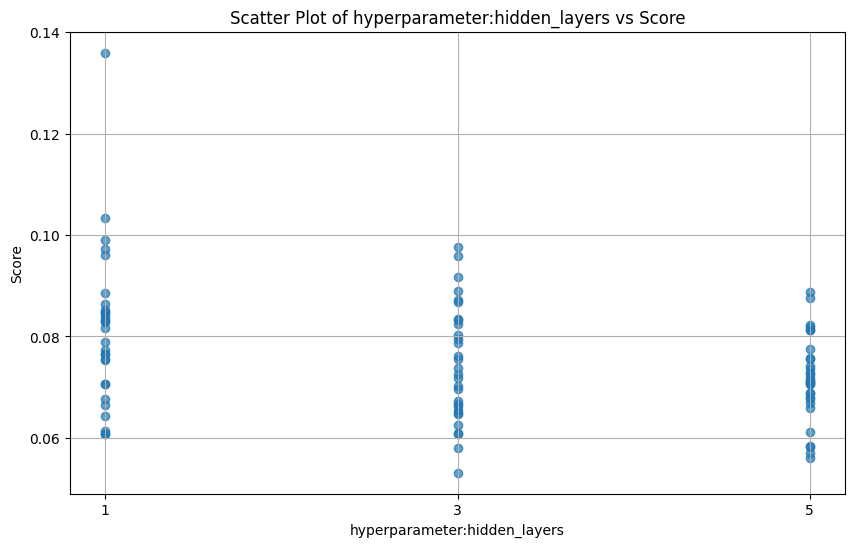

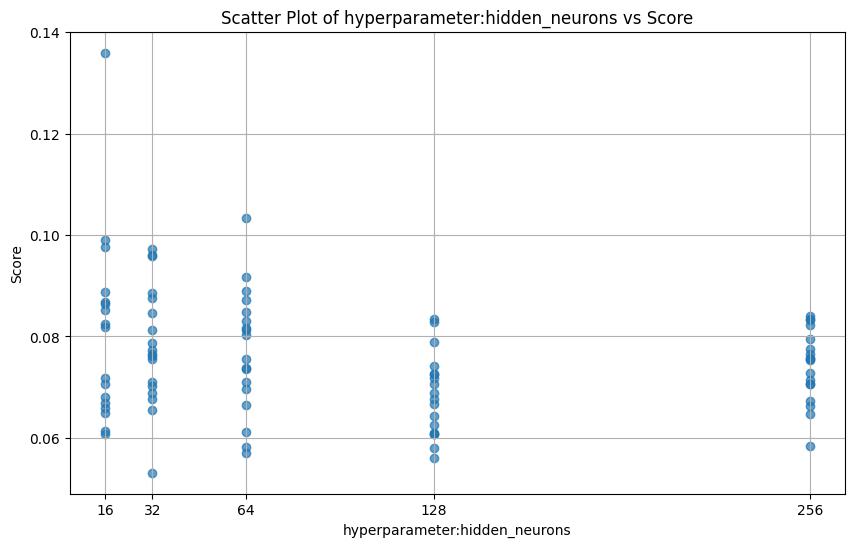

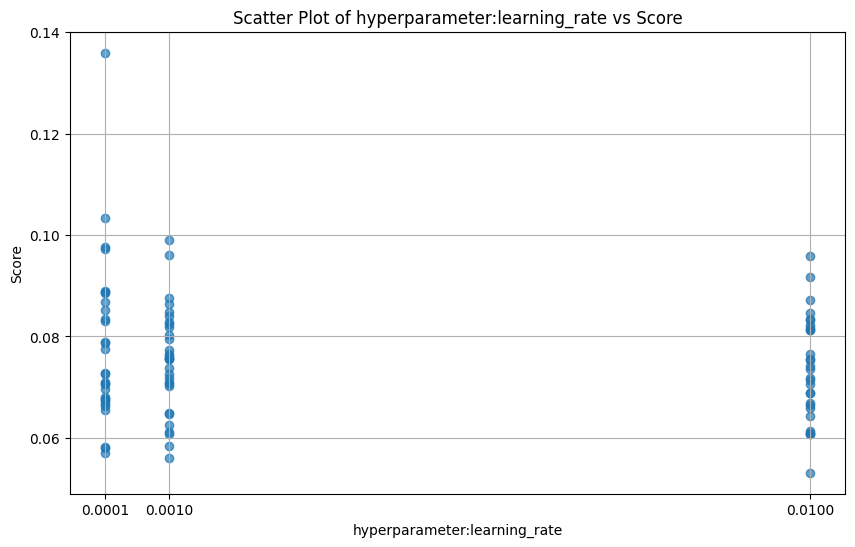

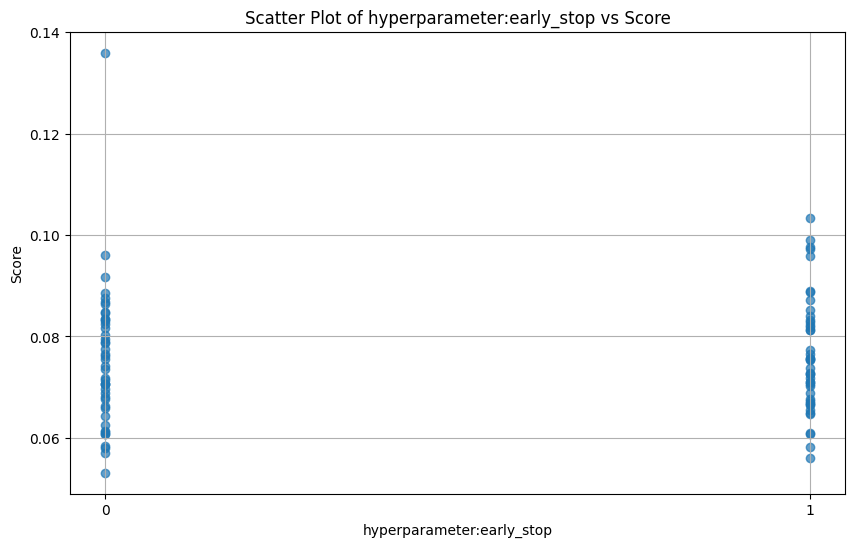

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and preprocess the DataFrame
df = pd.read_csv('../../data/hypertuner_output/tuner_sin_cos_mf/trial_results_.csv')

# Define column names and extract hyperparameters
columns = ['Trial ID', 'Hyperparameters', 'Score', 'Status']
df.columns = columns

# Expand hyperparameters into separate columns
hyperparameters_dict = df['Hyperparameters'].apply(eval)
hyperparameters_df = pd.json_normalize(hyperparameters_dict)
hyperparameters_df.columns = [f'hyperparameter:{col}' for col in hyperparameters_df.columns]

# Combine the hyperparameters with the original DataFrame
df = pd.concat([df.drop(columns='Hyperparameters'), hyperparameters_df], axis=1)

# Plot scatter plots for each hyperparameter
hyperparameter_columns = [col for col in df.columns if col.startswith('hyperparameter:')]
score_column = 'Score'

for param_col in hyperparameter_columns:
    unique_values = df[param_col].dropna().unique()
    plt.figure(figsize=(10, 6))
    plt.scatter(df[param_col], df[score_column], alpha=0.7)
    
    # Set x-axis ticks to only include unique values
    plt.xticks(sorted(unique_values))
    
    plt.xlabel(param_col)
    plt.ylabel(score_column)
    plt.title(f'Scatter Plot of {param_col} vs {score_column}')
    plt.grid(True)
    plt.show()


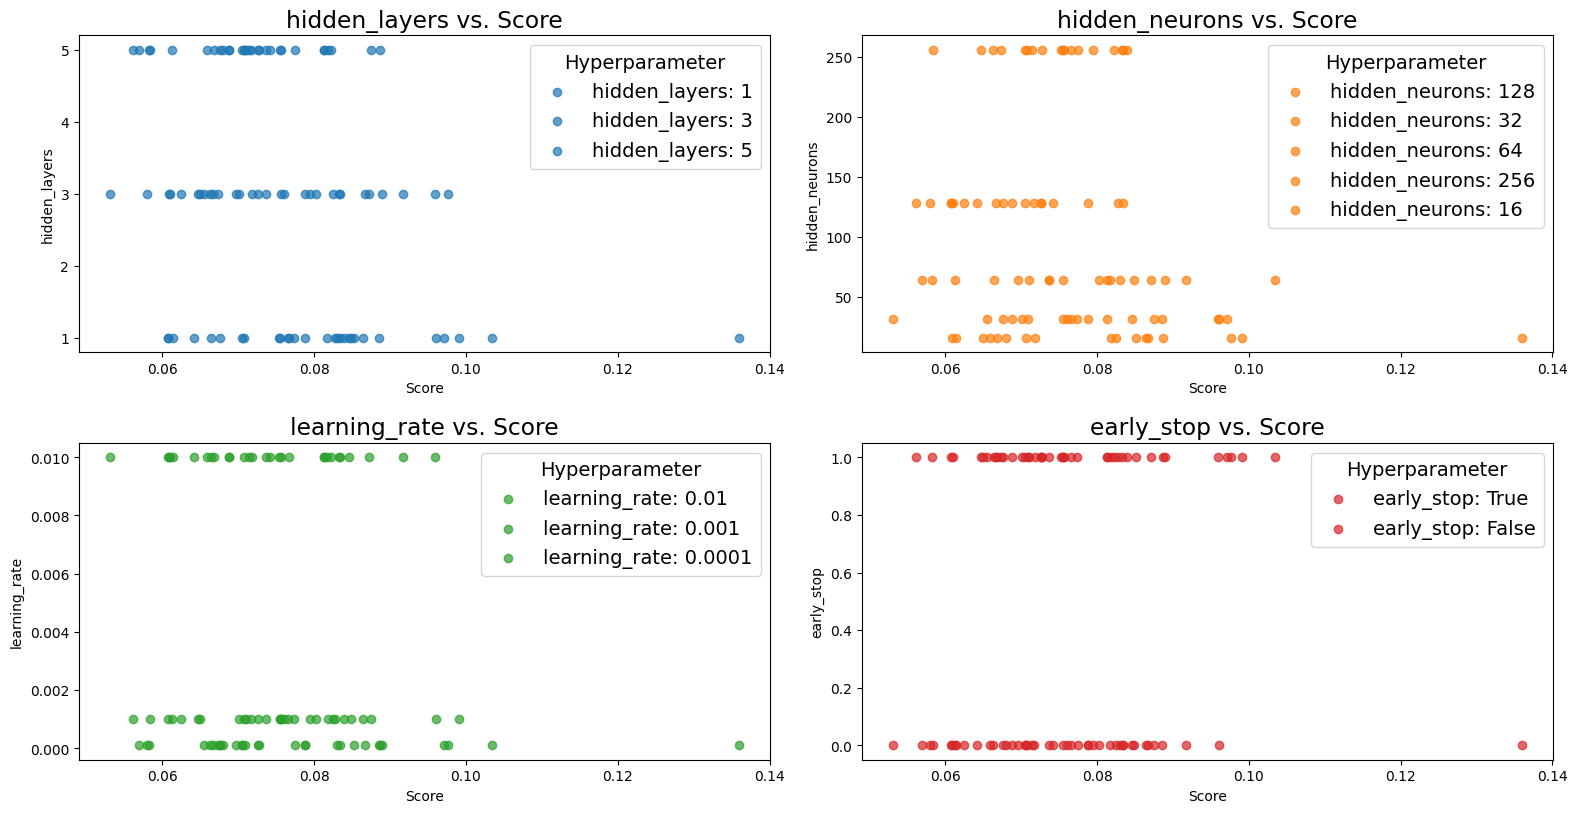

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data and preprocess
columns = ['Trial ID', 'Hyperparameters', 'Score', 'Status']
df = pd.read_csv('../../data/hypertuner_output/tuner_sin_cos_mf/trial_results_.csv')
df.columns = columns

# Expand hyperparameters and create separate columns
hyperparameters_dict = df['Hyperparameters'].apply(eval)
expanded_df = pd.json_normalize(hyperparameters_dict)

# Add hyperparameters columns to the dataframe
df = pd.concat([df.drop(columns=['Hyperparameters']), expanded_df], axis=1)

# Define the hyperparameters and their labels
hyperparameters = ['hidden_layers', 'hidden_neurons', 'learning_rate', 'early_stop']
color_map = plt.get_cmap('tab10')  # Get a colormap with distinct colors

# Create subplots with smaller individual plots and two columns
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 12))
axes = axes.flatten()

# Increase font size globally
plt.rcParams.update({'font.size': 14})

for i, param in enumerate(hyperparameters):
    ax = axes[i]
    unique_values = df[param].unique()
    # Scatter plot for each hyperparameter
    for value in unique_values:
        subset = df[df[param] == value]
        ax.scatter(subset['Score'], subset[param], label=f'{param}: {value}', c=[color_map(i)], alpha=0.7)
    
    ax.set_xlabel('Score')
    ax.set_ylabel(param)
    ax.set_title(f'{param} vs. Score')
    ax.legend(title='Hyperparameter', loc='best')  # Legend inside the plot

# Hide any unused subplots
for i in range(len(hyperparameters), len(axes)):
    fig.delaxes(axes[i])

fig.tight_layout()
plt.show()


In [ ]:
pio.renderers.default = 'iframe'  

In [9]:
exp = exp5

metrics = '../../data/model_output/{exp}/average_metrics_{exp}.csv'
metrics = pd.read_csv(metrics)
hf = []
mf = []

for i in range(5):
    outer = '../../data/model_output/{exp}/model_QC_--kfold-{i}/'
    hf.append(pd.read_csv(outer+'heat_flux-neural_network_scaled_metrics_NN'))
    mf.append(pd.read_csv(outer+'momentum_flux-neural_network_scaled_metrics_NN'))

# fill here chop off hf unneeded rows
# fill here chop off mf    ||     ||

# fill here compute average, add to average metridcs (for both hf and mf)

NameError: name 'exp5' is not defined

In [16]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [19]:
import pandas as pd

exp = 'exp3_yesES'
metrics_df = pd.read_csv(f'../../data/model_output/{exp}/average_metrics_{exp}.csv')
hf = []
mf = []

for i in range(5):
    outer = f'../../data/model_output/{exp}/model_QC_--kfold-{i}/'
    hf.append(pd.read_csv(outer + 'heat_flux-neural_network_scaled_metrics_NN.csv'))
    mf.append(pd.read_csv(outer + 'momentum_flux-neural_network_scaled_metrics_NN.csv'))
    print

# Chop off hf unneeded rows
for i in range(len(hf)):
    hf[i] = hf[i].iloc[[0, 4]]

# Chop off mf unneeded rows
for i in range(len(mf)):
    mf[i] = mf[i].iloc[:2]

# Compute average for hf
hf_concat = pd.concat(hf)
hf_mean = hf_concat.mean().to_frame().T
hf_mean['metric_type'] = 'heat_flux'

# Compute average for mf
mf_concat = pd.concat(mf)
mf_mean = mf_concat.mean().to_frame().T
mf_mean['metric_type'] = 'momentum_flux'

# Add to average metrics
average_metrics = pd.concat([hf_concat, mf_concat, hf_mean, mf_mean])

# Specify new file path for saving averages
new_metrics = f'../../data/model_output/{exp}/average_metrics_{exp}_new.csv'

# Save the updated metrics to the new file
# average_metrics.to_csv(new_metrics, index=False)
print(average_metrics)

   mean_squared_error  mean_absolute_error  mean_error  pearson_r2  \
0            0.001158             0.022867    0.004019    0.600388   
4            0.000000             0.000000    0.000000    0.000000   
0            0.000870             0.019146    0.007895    0.553799   
4            0.000000             0.000000    0.000000    0.000000   
0            0.001629             0.024210    0.000022    0.791542   
4            0.000000             0.000000    0.000000    0.000000   
0            0.002384             0.029498   -0.006833    0.851467   
4            0.000000             0.000000    0.000000    0.000000   
0            0.001945             0.026071   -0.005748    0.835419   
4            0.000000             0.000000    0.000000    0.000000   
0            0.244018             0.416711   -0.286708    0.600388   
1            0.000000             0.000000    0.000000    0.000000   
0            0.256322             0.451817   -0.369542    0.553799   
1            0.00000

# Most stuff

In [8]:
#!/usr/bin/env python
import numpy as np
import math
import yaml
import argparse
import pandas as pd 
#from mlsurfacelayer.data import load_derived_data
from mlsurfacelayer.mvco_data_QC import load_derived_data_random_test_train
from mlsurfacelayer.mvco_data_QC import load_derived_data_random_test_train_val
from mlsurfacelayer.models import save_random_forest_csv, save_scaler_csv
from mlsurfacelayer.mo import * 

from mlsurfacelayer.mo import computeMOSTfluxes

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from mlsurfacelayer.models import DenseNeuralNetwork
from mlsurfacelayer.explain import feature_importance
from os import makedirs
from os.path import exists, join
from sklearn.metrics import mean_squared_error, mean_absolute_error
from mlsurfacelayer.metrics import mean_error, hellinger_distance, pearson_r2
import pickle
from keras.models import save_model

model_classes = {"random_forest": RandomForestRegressor,
                 "neural_network": DenseNeuralNetwork}

metrics = {"mean_squared_error": mean_squared_error,
           "mean_absolute_error": mean_absolute_error,
           "pearson_r2": pearson_r2,
           "hellinger_distance": hellinger_distance,
           "mean_error": mean_error}


In [97]:
def comp_(exp_name):
    df_list = []

    with open(f'../config/{exp_name}.yml', "r") as config_file:
        config = yaml.load(config_file,Loader=yaml.FullLoader)

    for i in range(config['k_fold_cross_validation']['N']):
    # for i in range(2):
        with open(f'../../data/model_output/{exp_name}/{exp_name}--kfold-{i}.yml', "r") as config_file:
            config = yaml.load(config_file,Loader=yaml.FullLoader)
        
        # split data into fold, use the associated yml file
        data = load_derived_data_random_test_train_val(config['data_file'], dropna=True, devVar=config['k_fold_cross_validation']['devVar'],N=config['k_fold_cross_validation']['N'],k=config['k_fold_cross_validation']['k'],holdout_ratio=config['k_fold_cross_validation']['holdout_ratio'],scramble=config['k_fold_cross_validation']['scramble'],config=config)
        
        for a in data: # iterates through the train, val, & test, sets to apply the change
            data[a]['momentum_flux:18.4_m:m2_s-2'] = data[a]['momentum_flux:18.4_m:m2_s-2'].replace(-0.0, 0)
    
        model_metrics = pd.DataFrame(0, index=['momentum_flux-mo', 'heat_flux-mo'], columns=config["model_metric_types"], dtype=np.float32)
        
        for output_type in config['output_columns']:
            mo_predictand_label = output_type + "-" + "mo"

            for model_metric in config["model_metric_types"]:
                valid_indices = ~np.isnan(data["test"][config["output_columns"][output_type]].values) & ~np.isnan(data['test']['MOST_' + config["output_columns"][output_type].replace('C','K')].values)

                model_metrics.loc[mo_predictand_label,model_metric] = metrics[model_metric](data["test"][config["output_columns"][output_type]].values[valid_indices], data['test']['MOST_' + config["output_columns"][output_type].replace('C','K')].values[valid_indices])
        # add line here that adds to the end of the metrics another columns called "nan_count", will show how any nans where in the MOST section
        model_metrics['nan_count'] = len(~np.isnan(data['test']['MOST_' + config["output_columns"][output_type].replace('C','K')].values))
        model_metrics['nan_count2'] = len(~np.isnan(data["test"][config["output_columns"][output_type]].values))
        model_metrics['total_count'] = len(data['test'])
        
        model_metrics.to_csv(f'../../data/model_output/{exp_name}/model_QC_--kfold-{i}/most_metrics.csv', index_label="Model")
        df = pd.read_csv(f'../../data/model_output/{exp_name}/model_QC_--kfold-{i}/most_metrics.csv')
        df['kfold'] = i                                               # Add a column to identify the k-fold
        df_list.append(df)  
    
    print(model_metrics, 'last opened before cobining')
    
    combined_df = pd.concat(df_list, ignore_index=True)                 # Concatenate all dataframes in the list into a single dataframe

    average_metrics = combined_df.groupby('Model').mean().reset_index() # Compute the average of the metrics across all folds

    average_metrics.to_csv(f'../../data/model_output/{exp_name}/average_MOST_metrics_{exp_name}.csv', index=False) # Save the result to a new CSV file
    print(average_metrics)


In [98]:

comp_(exp_name='exp4')

NaNs dropped successfully.
data loaded, fold number: 0


C:\Users\hmarrero\AppData\Local\Temp\ipykernel_14504\912518579.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.0009443749792960851' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  model_metrics.loc[mo_predictand_label,model_metric] = metrics[model_metric](data["test"][config["output_columns"][output_type]].values[valid_indices], data['test']['MOST_' + config["output_columns"][output_type].replace('C','K')].values[valid_indices])
C:\Users\hmarrero\AppData\Local\Temp\ipykernel_14504\912518579.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.021911626565123975' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  model_metrics.loc[mo_predictand_label,model_metric] = metrics[model_metric](data["test"][config["output_columns"][output_type]].values[valid_ind

NaNs dropped successfully.
data loaded, fold number: 1


C:\Users\hmarrero\AppData\Local\Temp\ipykernel_14504\912518579.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.0008632641863322446' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  model_metrics.loc[mo_predictand_label,model_metric] = metrics[model_metric](data["test"][config["output_columns"][output_type]].values[valid_indices], data['test']['MOST_' + config["output_columns"][output_type].replace('C','K')].values[valid_indices])
C:\Users\hmarrero\AppData\Local\Temp\ipykernel_14504\912518579.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.019268983930670093' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  model_metrics.loc[mo_predictand_label,model_metric] = metrics[model_metric](data["test"][config["output_columns"][output_type]].values[valid_ind

NaNs dropped successfully.
data loaded, fold number: 2


...

NaNs dropped successfully.
data loaded, fold number: 3


C:\Users\hmarrero\AppData\Local\Temp\ipykernel_14504\912518579.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.003086914076623841' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  model_metrics.loc[mo_predictand_label,model_metric] = metrics[model_metric](data["test"][config["output_columns"][output_type]].values[valid_indices], data['test']['MOST_' + config["output_columns"][output_type].replace('C','K')].values[valid_indices])
C:\Users\hmarrero\AppData\Local\Temp\ipykernel_14504\912518579.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.0325151576845631' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  model_metrics.loc[mo_predictand_label,model_metric] = metrics[model_metric](data["test"][config["output_columns"][output_type]].values[valid_indice

NaNs dropped successfully.
data loaded, fold number: 4
                  mean_squared_error  mean_absolute_error  mean_error  \
momentum_flux-mo            0.002508             0.030224    0.001326   
heat_flux-mo                0.003014             0.029770    0.027712   

                  pearson_r2  nan_count  nan_count2  total_count  
momentum_flux-mo    0.804062      10962       10962        10962  
heat_flux-mo        0.831779      10962       10962        10962   last opened before cobining


C:\Users\hmarrero\AppData\Local\Temp\ipykernel_14504\912518579.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.0030138791929578746' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  model_metrics.loc[mo_predictand_label,model_metric] = metrics[model_metric](data["test"][config["output_columns"][output_type]].values[valid_indices], data['test']['MOST_' + config["output_columns"][output_type].replace('C','K')].values[valid_indices])
C:\Users\hmarrero\AppData\Local\Temp\ipykernel_14504\912518579.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.029770072763089968' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  model_metrics.loc[mo_predictand_label,model_metric] = metrics[model_metric](data["test"][config["output_columns"][output_type]].values[valid_ind

              Model  mean_squared_error  mean_absolute_error  mean_error  \
0      heat_flux-mo            0.001887             0.026048    0.023970   
1  momentum_flux-mo            0.002227             0.028777    0.002667   

   pearson_r2  nan_count  nan_count2  total_count  kfold  
0    0.640754    10962.0     10962.0      10962.0    2.0  
1    0.737137    10962.0     10962.0      10962.0    2.0  


In [82]:
model_metrics

,mean_squared_error,mean_absolute_error,mean_error,pearson_r2
Model,,,,
momentum_flux-random_forest,0.000000,0.000000,0.000000,0.000000
momentum_flux-neural_network,0.000000,0.000000,0.000000,0.000000
momentum_flux-mo,0.002508,0.030224,0.001326,0.804062
heat_flux-random_forest,0.000000,0.000000,0.000000,0.000000
heat_flux-neural_network,0.000000,0.000000,0.000000,0.000000
heat_flux-mo,0.003014,0.029770,0.027712,0.831779


In [84]:
model_metrics

,mean_squared_error,mean_absolute_error,mean_error,pearson_r2
Model,,,,
momentum_flux-random_forest,0.000000,0.000000,0.000000,0.000000
momentum_flux-neural_network,0.000000,0.000000,0.000000,0.000000
momentum_flux-mo,0.002508,0.030224,0.001326,0.804062
heat_flux-random_forest,0.000000,0.000000,0.000000,0.000000
heat_flux-neural_network,0.000000,0.000000,0.000000,0.000000
heat_flux-mo,0.003014,0.029770,0.027712,0.831779


# checking if MOST metric is accurate

In [1]:
#!/usr/bin/env python
import numpy as np
import math
import yaml
import argparse
import pandas as pd 
#from mlsurfacelayer.data import load_derived_data
from mlsurfacelayer.mvco_data_QC import load_derived_data_random_test_train
from mlsurfacelayer.mvco_data_QC import load_derived_data_random_test_train_val
from mlsurfacelayer.models import save_random_forest_csv, save_scaler_csv
from mlsurfacelayer.mo import * 

from mlsurfacelayer.mo import computeMOSTfluxes

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from mlsurfacelayer.models import DenseNeuralNetwork
from mlsurfacelayer.explain import feature_importance
from os import makedirs
from os.path import exists, join
from sklearn.metrics import mean_squared_error, mean_absolute_error
from mlsurfacelayer.metrics import mean_error, hellinger_distance, pearson_r2
import pickle
from keras.models import save_model

model_classes = {"random_forest": RandomForestRegressor,
                 "neural_network": DenseNeuralNetwork}

metrics = {"mean_squared_error": mean_squared_error,
           "mean_absolute_error": mean_absolute_error,
           "pearson_r2": pearson_r2,
           "hellinger_distance": hellinger_distance,
           "mean_error": mean_error}

In [ ]:


def comp_(exp_name):
    df_list = []

    with open(f'../config/{exp_name}.yml', "r") as config_file:
        config = yaml.load(config_file,Loader=yaml.FullLoader)

    for i in range(config['k_fold_cross_validation']['N']):
    # for i in range(2):
        with open(f'../../data/model_output/{exp_name}/{exp_name}--kfold-{i}.yml', "r") as config_file:
            config = yaml.load(config_file,Loader=yaml.FullLoader)
        
        # split data into fold, use the associated yml file
        # data = load_derived_data_random_test_train_val(config['data_file'], dropna=True, devVar=config['k_fold_cross_validation']['devVar'],N=config['k_fold_cross_validation']['N'],k=config['k_fold_cross_validation']['k'],holdout_ratio=config['k_fold_cross_validation']['holdout_ratio'],scramble=config['k_fold_cross_validation']['scramble'],config=config)
        # for a in data: # iterates through the train, val, & test, sets to apply the change
        #     data[a]['momentum_flux:18.4_m:m2_s-2'] = data[a]['momentum_flux:18.4_m:m2_s-2'].replace(-0.0, 0)

        data = pd.read_csv(f'../../data/model_output/{exp_name}/model_QC_--kfold-{i}/surface_layer_model_predictions.csv')

        model_metrics = pd.DataFrame(0, index=['momentum_flux-mo', 'heat_flux-mo'], columns=config["model_metric_types"], dtype=np.float32)
        
        for output_type in config['output_columns']:
            mo_predictand_label = output_type + "-" + "mo"

            for model_metric in config["model_metric_types"]:
                # valid_indices = ~np.isnan(data["test"][config["output_columns"][output_type]].values) & ~np.isnan(data['test']['MOST_' + config["output_columns"][output_type].replace('C','K')].values)
                valid_indices = ~np.isnan(data[config["output_columns"][output_type]].values) & ~np.isnan(data['MOST_' + config["output_columns"][output_type].replace('C','K')].values)

                # model_metrics.loc[mo_predictand_label,model_metric] = metrics[model_metric](data["test"][config["output_columns"][output_type]].values[valid_indices], data['test']['MOST_' + config["output_columns"][output_type].replace('C','K')].values[valid_indices])
                model_metrics.loc[mo_predictand_label,model_metric] = metrics[model_metric](data[config["output_columns"][output_type]].values[valid_indices], data['MOST_' + config["output_columns"][output_type].replace('C','K')].values[valid_indices])
        # add line here that adds to the end of the metrics another columns called "nan_count", will show how any nans where in the MOST section
        model_metrics['nan_count'] = len(~np.isnan(data['MOST_' + config["output_columns"][output_type].replace('C','K')].values))
        model_metrics['nan_count2'] = len(~np.isnan(data[config["output_columns"][output_type]].values))
        model_metrics['total_count'] = len(data)
        
        model_metrics.to_csv(f'../../data/model_output/{exp_name}/model_QC_--kfold-{i}/most_metrics.csv', index_label="Model")
        df = pd.read_csv(f'../../data/model_output/{exp_name}/model_QC_--kfold-{i}/most_metrics.csv')
        df['kfold'] = i                                               # Add a column to identify the k-fold
        df_list.append(df)  
    
    print(model_metrics, 'last opened before cobining')
    
    combined_df = pd.concat(df_list, ignore_index=True)                 # Concatenate all dataframes in the list into a single dataframe

    average_metrics = combined_df.groupby('Model').mean().reset_index() # Compute the average of the metrics across all folds

    average_metrics.to_csv(f'../../data/model_output/{exp_name}/average_MOST_metrics_{exp_name}.csv', index=False) # Save the result to a new CSV file
    print(average_metrics)


if __name__ == "__main__":
    # comp_(exp_name='exp_derivs_sfcVars')
    # comp_(exp_name='exp_heightDependent')
    comp_(exp_name='exp4')

In [21]:
exp_name = 'exp6'
i = 0

heat_flux = 'heat_flux:18.4_m:degrees_C_m_s-1'
momentum_flux = 'momentum_flux:18.4_m:m2_s-2'

output_t = momentum_flux
# exp_name = 'exp_derivs_sfcVars_nn_ltd_noDir'
# exp_name = 'exp_derivs_sfcVars_rf_ltd_noDir'

# data = pd.read_csv(f'../../data/model_output/{exp_name}/model_QC_--kfold-{i}/surface_layer_model_predictions.csv')
data = pd.read_csv(f'../../data/mvco_mlsl_qc.csv')

print(data[output_t].isna().sum())
print(data['MOST_'+output_t].isna().sum())

print(f'lenth of data {len(data)}')
data = data.dropna(subset=momentum_flux)
print(f'length of data after dropna {len(data)}')


print(f'lenth of data {len(data)}')
data = data.dropna(subset='MOST_'+output_t)
print(f'length of data after dropna {len(data)}')

# data = data.dropna(subset=input_columns)

# valid_indices = ~np.isnan(data[output_t].values) & ~np.isnan(data['MOST_'+output_t].values)

sadie = pd.DataFrame()

# model_metrics.loc[mo_predictand_label,model_metric] = metrics[model_metric](data["test"][config["output_columns"][output_type]].values[valid_indices], data['test']['MOST_' + config["output_columns"][output_type].replace('C','K')].values[valid_indices])

# sadie['mo'] = metrics['mean_absolute_error'](data[output_t].values[valid_indices], data['MOST_'+output_t].values[valid_indices])
a = data[output_t].values
b = data['MOST_'+output_t].values

print(data[output_t].isna().sum())
print(data['MOST_'+output_t].isna().sum())

# print(metrics['mean_absolute_error'](a,b))

sadie['mo'] = metrics['mean_absolute_error'](a, b)

print(sadie['mo'])


lenth of data 416851
length of data after dropna 174968
0
113876


ValueError: Input contains NaN.

In [8]:
print(data.columns)

Index(['Time', 'momentum_flux-neural_network', 'momentum_flux-random_forest',
       'momentum_flux-mo', 'heat_flux-neural_network',
       'heat_flux-random_forest', 'heat_flux-mo', 'temperature:18.4_m:K',
       'water_sfc_temperature:0_m:K', 'pressure:18.4_m:hPa',
       'potential_temperature:18.4_m:K',
       'skin_virtual_potential_temperature:0_m:K', 'mixing_ratio:0_m:g_kg-1',
       'mixing_ratio:18.4_m:g_kg-1', 'relative_humidity:18.4_m:%',
       'wave_direction:0_m:degrees', 'wave_height:0_m:m', 'wave_period:0_m:s',
       'wave_phase_speed:0_m:m_s-1', 'near_surf_current:0_m:m_s-1',
       'near_surf_current_dir:0_m:deg', 'wind_speed:18.4_m:m_s-1',
       'wind_direction:18.4_m:degrees', 'angle_between_wind_wave:0_m:degrees',
       'u_wind:18.4_m:m_s-1', 'v_wind:18.4_m:m_s-1',
       'bulk_richardson:18.4_m:none', 'u_w:18.4_m:m2_s-2', 'v_w:18.4_m:m2_s-2',
       'dT_dz:18.4_m:K_m-1', 'dSpeed_dz:18.4_m:s-1',
       'MOST_momentum_flux:18.4_m:m2_s-2',
       'MOST_heat_flux:1

hf
ghi

mf 